In [1]:
import pandas as pd
import numpy as np
import en_core_web_sm

# Import plotly
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
# setting div color palette as default
pio.templates["div"] = go.layout.Template(
    layout_colorway=["#0E6AA0", "#5AF7B5", "#13242E", "#5FFC66", "#1C6406", "#AC49B9", "#E6E33D", "#520A4E"]
)
pio.templates.default = "div"
pio.renderers.default = "svg" # to be replaced by "iframe" if working on JULIE

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import DBSCAN
from sklearn.decomposition import TruncatedSVD

import matplotlib.pyplot as plt
import wordcloud


In [2]:
df = pd.read_csv("sample-data.csv", index_col="id")
df.head()

,description
id,
1,Active classic boxers - There's a reason why o...
2,Active sport boxer briefs - Skinning up Glory ...
3,Active sport briefs - These superbreathable no...
4,"Alpine guide pants - Skin in, climb ice, switc..."
5,"Alpine wind jkt - On high ridges, steep ice an..."


In [3]:
def affichage(donnees, col):
    for i, desc in enumerate(donnees[col].head()):
        print(f"Description {i+1}:")
        print(desc)
        print("-" * 50)

affichage(df, "description")

Description 1:
Active classic boxers - There's a reason why our boxers are a cult favorite - they keep their cool, especially in sticky situations. The quick-drying, lightweight underwear takes up minimal space in a travel pack. An exposed, brushed waistband offers next-to-skin softness, five-panel construction with a traditional boxer back for a classic fit, and a functional fly. Made of 3.7-oz 100% recycled polyester with moisture-wicking performance. Inseam (size M) is 4 1/2". Recyclable through the Common Threads Recycling Program.<br><br><b>Details:</b><ul> <li>"Silky Capilene 1 fabric is ultralight, breathable and quick-to-dry"</li> <li>"Exposed, brushed elastic waistband for comfort"</li> <li>5-panel construction with traditional boxer back</li> <li>"Inseam (size M) is 4 1/2"""</li></ul><br><br><b>Fabric: </b>3.7-oz 100% all-recycled polyester with Gladiodor natural odor control for the garment. Recyclable through the Common Threads Recycling Program<br><br><b>Weight: </b>99 g (

#### Preprocessing dans Pandas pour enlever les balises html, et made in ..., les poids, et virer "Recyclable through the Common Threads Recycling Program", ponctuation et mettre en minuscules

In [4]:
data = df.copy()

# Suppression "Recyclage through ..."
data["description"] = data["description"].str.replace(r'Recyclable through the Common Threads Recycling Program', "", regex=True)
# affichage(data, "description")


In [5]:
# Suppression après fabrics dont poids et made in
data["description"] = data["description"].str.replace(r'Weight:.*', "", regex=True)
# affichage(data, "description")

In [6]:
# Suppression des balises HTML
data["description"] = data["description"].str.replace(r'<[^>]+>', "", regex=True)
# affichage(data, "description")

In [7]:
# Suppression ponctuation + chiffres
data["description"] = data['description'].str.replace(r'[^A-Za-z ]+', "", regex=True)
affichage(data, "description")

Description 1:
Active classic boxers  Theres a reason why our boxers are a cult favorite  they keep their cool especially in sticky situations The quickdrying lightweight underwear takes up minimal space in a travel pack An exposed brushed waistband offers nexttoskin softness fivepanel construction with a traditional boxer back for a classic fit and a functional fly Made of oz  recycled polyester with moisturewicking performance Inseam size M is   Details Silky Capilene  fabric is ultralight breathable and quicktodry Exposed brushed elastic waistband for comfort panel construction with traditional boxer back Inseam size M is  Fabric oz  allrecycled polyester with Gladiodor natural odor control for the garment 
--------------------------------------------------
Description 2:
Active sport boxer briefs  Skinning up Glory requires enough movement without your boxers deciding to poach their own route The formfitting Active Sport Boxer Briefs are made from breathable  polyester  recycled fa

In [8]:
# # Supprimer les mesures/pourcentages isolés
# data["description"] = data["description"].str.replace(r'\boz\b|\bdenier\b|%|\b\d+(?:\.\d+)?\b', "", regex=True)
# affichage(data, "description")

In [9]:
# Suppression Majuscules
data["description"] = data["description"].fillna("").apply(lambda x: x.lower())
# affichage(data, "description")

In [10]:
data["description"] = data["description"].str.replace(r'\s+', '*', regex=True).str.replace(r"*", " ", regex=False)
affichage(data, "description")

Description 1:
active classic boxers theres a reason why our boxers are a cult favorite they keep their cool especially in sticky situations the quickdrying lightweight underwear takes up minimal space in a travel pack an exposed brushed waistband offers nexttoskin softness fivepanel construction with a traditional boxer back for a classic fit and a functional fly made of oz recycled polyester with moisturewicking performance inseam size m is details silky capilene fabric is ultralight breathable and quicktodry exposed brushed elastic waistband for comfort panel construction with traditional boxer back inseam size m is fabric oz allrecycled polyester with gladiodor natural odor control for the garment 
--------------------------------------------------
Description 2:
active sport boxer briefs skinning up glory requires enough movement without your boxers deciding to poach their own route the formfitting active sport boxer briefs are made from breathable polyester recycled fabric thats 

##### Preprocessing NLP

In [11]:
nlp = en_core_web_sm.load()

In [12]:
from spacy.lang.en.stop_words import STOP_WORDS

# Tokenisation
data["tokenized"] = data["description"].fillna("").apply(lambda x: nlp(x))
# data.head()

In [13]:
# Lemmatisation
data["tokenized"] = data["tokenized"].apply(lambda doc: [token.lemma_ for token in doc if token.text not in STOP_WORDS])
# data.head()

In [14]:
# Detokenisation
data["nlp_ready"] = data["tokenized"].apply(lambda x: " ".join(x))
data.head()

,description,tokenized,nlp_ready
id,,,
1,active classic boxers theres a reason why our ...,"[active, classic, boxer, s, reason, boxer, cul...",active classic boxer s reason boxer cult favor...
2,active sport boxer briefs skinning up glory re...,"[active, sport, boxer, brief, skin, glory, req...",active sport boxer brief skin glory require mo...
3,active sport briefs these superbreathable nofl...,"[active, sport, brief, superbreathable, nofly,...",active sport brief superbreathable nofly brief...
4,alpine guide pants skin in climb ice switch to...,"[alpine, guide, pant, skin, climb, ice, switch...",alpine guide pant skin climb ice switch rock t...
5,alpine wind jkt on high ridges steep ice and a...,"[alpine, wind, jkt, high, ridge, steep, ice, a...",alpine wind jkt high ridge steep ice alpine ja...


In [15]:
# TF-IDF transformation vector
vectorizer = TfidfVectorizer(stop_words="english")
X = vectorizer.fit_transform(data["nlp_ready"])
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 30186 stored elements and shape (500, 4342)>

In [16]:
# affichage(data, "nlp_ready")

### Part 1 : Groups of products with similar descriptions

In [17]:
# Instance dbscan
db = DBSCAN(eps=0.7, min_samples=5, metric="cosine", algorithm="brute")
db.fit(X)
labels = db.labels_
labels_pd = pd.Series(labels)
print("Nombre par label")
print(labels_pd.value_counts(ascending=False))

Nombre par label
 1     128
-1     126
 4      55
 0      49
 8      24
 2      21
 6      18
 9      10
 13      9
 3       9
 5       8
 11      8
 14      7
 12      7
 7       6
 16      5
 15      5
 10      5
Name: count, dtype: int64


In [18]:
unique_clusters = np.unique(labels)
print(f"Clusters trouvés : {unique_clusters}")

Clusters trouvés : [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]


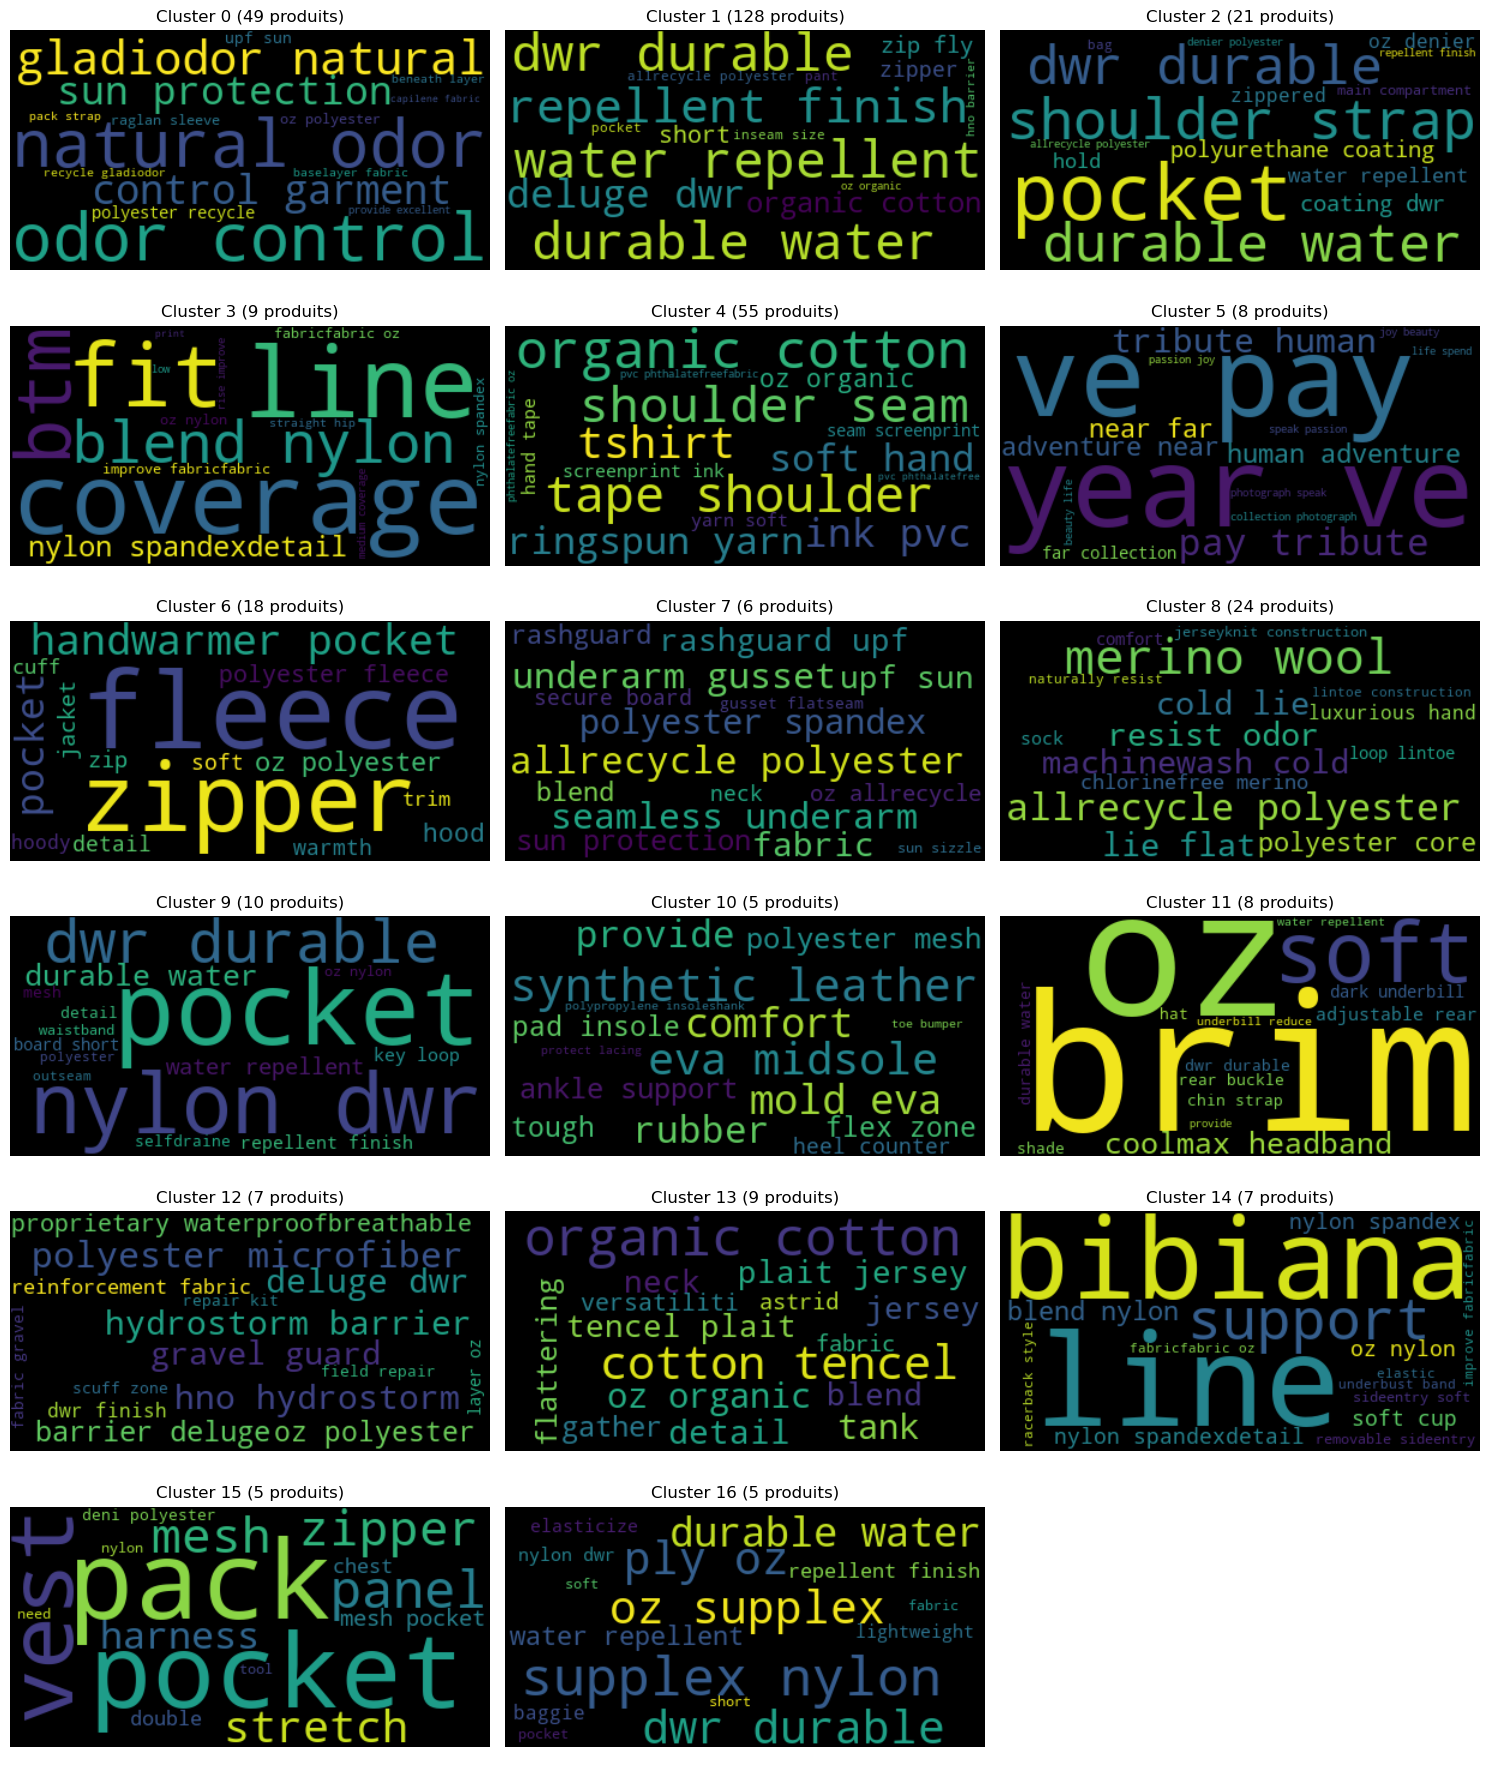

In [25]:
import math
from collections import Counter
wc = wordcloud.WordCloud(stopwords=STOP_WORDS, max_words=15)

# for cluster_id in unique_clusters:
#     if cluster_id == -1:  # Skip outliers
#         continue
#     cluster_id_mask = (labels == cluster_id) # mask sur l'indice
#     produits_cluster_id = data[cluster_id_mask]  
#     textes_cluster_id = produits_cluster_id['nlp_ready'].tolist()  # liste de tous les docs
#     texte_combine_cluster_id = " ".join(textes_cluster_id)  # ts les docs en 1 élément

#     cloud = wc.generate(texte_combine_cluster_id)
#     plt.imshow(cloud)
#     plt.title(f'Cluster {cluster_id} ({len(textes_cluster_id)} produits)')
#     plt.axis('off')  # Enlever les axes pour un rendu plus propre
#     plt.show()

def create_wordcloud_grid(unique_clusters, labels, data, wc, cols=3, figsize_per_plot=(5, 3)):
    """
    Crée une grille de wordclouds avec un nombre de colonnes fixe
    
    Args:
        unique_clusters: liste des clusters uniques
        labels: labels des clusters pour chaque point
        data: dataframe contenant les données
        wc: objet WordCloud configuré
        cols: nombre de colonnes souhaité
        figsize_per_plot: taille de chaque subplot
    """
    n_clusters = len(unique_clusters - 1)
    rows = math.ceil(n_clusters / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(figsize_per_plot[0]*cols, figsize_per_plot[1]*rows))
    
    # Gérer les différents cas de dimensions
    if n_clusters == 1:
        axes = [axes]
    elif rows == 1 or cols == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()
    
    plot_idx = 0
    for cluster_id in unique_clusters:
        if cluster_id == -1:
            continue
        
        cluster_id_mask = (labels == cluster_id)
        produits_cluster_id = data[cluster_id_mask]  
        textes_cluster_id = produits_cluster_id['nlp_ready'].tolist()
        texte_combine_cluster_id = " ".join(textes_cluster_id)
        cloud = wc.generate(texte_combine_cluster_id)
        
        axes[plot_idx].imshow(cloud, interpolation='bilinear')
        axes[plot_idx].set_title(f'Cluster {cluster_id} ({len(textes_cluster_id)} produits)')
        axes[plot_idx].axis('off')
        plot_idx += 1
    
    # Masquer les axes non utilisés
    for i in range(plot_idx, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    return fig

# Utilisation
fig = create_wordcloud_grid(unique_clusters, labels, data, wc, cols=3)
fig.savefig('wordclouds_grid.png', dpi=300, bbox_inches='tight')
plt.show()

### Part 2 - Recommender system

In [26]:
def find_similar_items(item_id):
    cluster_du_produit = labels[item_id - 1]
    produits_meme_cluster = data[labels == cluster_du_produit]
    produits_meme_cluster = produits_meme_cluster[produits_meme_cluster.index != item_id]
    echantillon = produits_meme_cluster.sample(5)
    return echantillon.index.tolist()


def check_val(valeur):
    try:
        valeur = int(valeur.strip())
        if (valeur > 0) and (valeur <= len(data)):
            return valeur
        else:
            print(f"Veuillez indiquer un id produit (nb entier) compris entre 1 et {len(data)}")
            choix_utilisateur = input("Choississez l'id d'un produit : ")
            return check_val(choix_utilisateur)
    except ValueError:
        print(f"{valeur} n'est pas un id produit valide, Veuillez entrer un id (nb entier) compris entre 1 et {len(data)}")
        choix_utilisateur = input("Choississez l'id d'un produit : ")
        return check_val(choix_utilisateur)
            
            
while True :
    choix_utilisateur = input("Choississez l'id d'un produit : ")
    id_produit = check_val(choix_utilisateur)
    similar_items = find_similar_items(id_produit)
    print(f"Ces articles pourraient vous plaire : {similar_items}")
    break

Ces articles pourraient vous plaire : [176, 378, 263, 413, 1]


### Part 3 : Topic modeling

In [27]:
svd_model = TruncatedSVD(n_components=20)
lsa = svd_model.fit_transform(X)

lsa

array([[ 0.21554163, -0.04584795,  0.14660885, ...,  0.03350224,
        -0.0592421 ,  0.10601225],
       [ 0.2028754 , -0.05283327,  0.0687123 , ...,  0.12819535,
        -0.12678678,  0.09376359],
       [ 0.17914617, -0.06420906,  0.08393471, ...,  0.08302426,
        -0.12232618,  0.03498367],
       ...,
       [ 0.29315611, -0.18765726, -0.02441746, ...,  0.04957408,
        -0.0113876 ,  0.02529929],
       [ 0.27252039,  0.0950655 , -0.19099132, ...,  0.06574182,
         0.08480588,  0.04755073],
       [ 0.30349408,  0.08480846, -0.24596533, ...,  0.08455552,
         0.05325945,  0.04223764]])

In [28]:
original_indexes = data["nlp_ready"].index
original_indexes

Index([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,
       ...
       491, 492, 493, 494, 495, 496, 497, 498, 499, 500],
      dtype='int64', name='id', length=500)

In [29]:
topic_encoded_df = pd.DataFrame(lsa, columns = [f"topic_{i + 1}" for i in range(20)], index=original_indexes)
topic_encoded_df

,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,topic_10,topic_11,topic_12,topic_13,topic_14,topic_15,topic_16,topic_17,topic_18,topic_19,topic_20
id,,,,,,,,,,,,,,,,,,,,
1,0.215542,-0.045848,0.146609,0.113671,-0.121193,0.007206,-0.098196,0.003047,-0.126542,0.018403,-0.005272,-0.067398,-0.003072,-0.019202,0.041918,-0.041243,0.016141,0.033502,-0.059242,0.106012
2,0.202875,-0.052833,0.068712,0.106328,-0.043394,-0.068990,0.003227,-0.028663,-0.104789,0.029615,-0.017056,-0.129054,0.080792,0.062808,-0.039693,-0.041951,-0.038711,0.128195,-0.126787,0.093764
3,0.179146,-0.064209,0.083935,0.038705,-0.034520,-0.064779,0.107725,-0.021811,-0.087951,-0.020121,-0.015484,-0.102210,0.131919,0.032759,-0.071469,-0.067808,-0.028790,0.083024,-0.122326,0.034984
4,0.340300,-0.199938,-0.092245,-0.118301,0.026787,-0.019814,-0.108984,-0.022386,-0.067878,0.141734,0.014586,-0.147371,-0.063009,-0.043998,-0.024912,0.024565,0.124550,-0.209764,-0.105517,-0.025265
5,0.384305,-0.219955,-0.012993,-0.247690,-0.010497,0.045348,0.023344,0.018136,0.015348,0.177801,0.029483,-0.163159,-0.122006,-0.120804,0.087575,-0.170307,-0.057101,0.036319,0.067293,0.019361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,0.301012,-0.079837,0.350798,0.104930,-0.288629,0.083290,-0.212020,-0.050053,-0.308470,-0.006654,-0.043498,-0.027305,-0.040957,-0.014834,0.007781,-0.044959,0.031279,-0.080333,0.011244,0.022968
497,0.315001,-0.072983,0.457309,0.029396,-0.325760,0.092723,-0.087711,0.038083,-0.224246,-0.049852,-0.042334,0.026244,-0.123312,-0.028311,0.010406,-0.107008,0.031045,0.042121,0.099374,-0.137549
498,0.293156,-0.187657,-0.024417,-0.261863,0.024874,0.209471,0.002104,-0.144030,0.080904,-0.042825,0.028221,0.104208,0.029871,-0.004012,0.027504,-0.031257,0.019800,0.049574,-0.011388,0.025299


In [30]:
topic_encoded_df["main"] = lsa.argmax(axis=1) + 1

In [31]:
topic_encoded_df

,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,topic_10,...,topic_12,topic_13,topic_14,topic_15,topic_16,topic_17,topic_18,topic_19,topic_20,main
id,,,,,,,,,,,,,,,,,,,,,
1,0.215542,-0.045848,0.146609,0.113671,-0.121193,0.007206,-0.098196,0.003047,-0.126542,0.018403,...,-0.067398,-0.003072,-0.019202,0.041918,-0.041243,0.016141,0.033502,-0.059242,0.106012,1
2,0.202875,-0.052833,0.068712,0.106328,-0.043394,-0.068990,0.003227,-0.028663,-0.104789,0.029615,...,-0.129054,0.080792,0.062808,-0.039693,-0.041951,-0.038711,0.128195,-0.126787,0.093764,1
3,0.179146,-0.064209,0.083935,0.038705,-0.034520,-0.064779,0.107725,-0.021811,-0.087951,-0.020121,...,-0.102210,0.131919,0.032759,-0.071469,-0.067808,-0.028790,0.083024,-0.122326,0.034984,1
4,0.340300,-0.199938,-0.092245,-0.118301,0.026787,-0.019814,-0.108984,-0.022386,-0.067878,0.141734,...,-0.147371,-0.063009,-0.043998,-0.024912,0.024565,0.124550,-0.209764,-0.105517,-0.025265,1
5,0.384305,-0.219955,-0.012993,-0.247690,-0.010497,0.045348,0.023344,0.018136,0.015348,0.177801,...,-0.163159,-0.122006,-0.120804,0.087575,-0.170307,-0.057101,0.036319,0.067293,0.019361,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,0.301012,-0.079837,0.350798,0.104930,-0.288629,0.083290,-0.212020,-0.050053,-0.308470,-0.006654,...,-0.027305,-0.040957,-0.014834,0.007781,-0.044959,0.031279,-0.080333,0.011244,0.022968,3
497,0.315001,-0.072983,0.457309,0.029396,-0.325760,0.092723,-0.087711,0.038083,-0.224246,-0.049852,...,0.026244,-0.123312,-0.028311,0.010406,-0.107008,0.031045,0.042121,0.099374,-0.137549,3
498,0.293156,-0.187657,-0.024417,-0.261863,0.024874,0.209471,0.002104,-0.144030,0.080904,-0.042825,...,0.104208,0.029871,-0.004012,0.027504,-0.031257,0.019800,0.049574,-0.011388,0.025299,1


In [ ]:
# topic_encoded_df["max_value"] = topic_encoded_df.max(axis=1)
# topic_encoded_df["main_topic"] = topic_encoded_df.idxmax(axis=1)

In [32]:
svd_model.components_.shape

(20, 4342)

In [33]:
svd_model.components_

array([[ 0.00046982,  0.00132909,  0.00289699, ...,  0.00156328,
         0.00671041,  0.01069185],
       [-0.00026518, -0.00071224, -0.00114021, ..., -0.00103485,
        -0.00497465, -0.00916372],
       [ 0.00058523,  0.00325761,  0.00589652, ..., -0.00161928,
         0.00059647,  0.00127023],
       ...,
       [ 0.00852894, -0.00372116, -0.00489773, ..., -0.00069969,
         0.00190024, -0.02735246],
       [-0.00486955,  0.00054738,  0.00077748, ...,  0.0014255 ,
         0.02075669,  0.0247718 ],
       [ 0.00738892,  0.00561887,  0.00622007, ...,  0.00106411,
         0.01255392,  0.01465403]])

In [ ]:
svd_model.get_feature_names_out()

'truncatedsvd0'

In [38]:
np.argmax(svd_model.get_feature_names_out()[0])

np.int64(0)

In [ ]:
vectorizer.get_feature_names_out()

'bibiana'

In [46]:
val_abs_svd_model = np.absolute(svd_model.components_)
val_abs_svd_model

array([[0.00046982, 0.00132909, 0.00289699, ..., 0.00156328, 0.00671041,
        0.01069185],
       [0.00026518, 0.00071224, 0.00114021, ..., 0.00103485, 0.00497465,
        0.00916372],
       [0.00058523, 0.00325761, 0.00589652, ..., 0.00161928, 0.00059647,
        0.00127023],
       ...,
       [0.00852894, 0.00372116, 0.00489773, ..., 0.00069969, 0.00190024,
        0.02735246],
       [0.00486955, 0.00054738, 0.00077748, ..., 0.0014255 , 0.02075669,
        0.0247718 ],
       [0.00738892, 0.00561887, 0.00622007, ..., 0.00106411, 0.01255392,
        0.01465403]])

In [ ]:
val_abs_svd_model = np.absolute(svd_model.components_)
indices_svd_model = np.argmax(val_abs_svd_model, axis=1)
indices_svd_model

array([2709, 2518, 2246, 1858, 2246, 2518,  775, 2709, 3649, 1341, 2657,
        775, 1341, 2390,  775, 1341,  905, 3154, 2928, 3678])

In [51]:
indices_top15 = np.argsort(val_abs_svd_model, axis=1)[:, -15:][:, ::-1]
indices_top15

array([[2709, 2725, 2518,  762, 4332, 1226, 1062, 2558, 1055, 2457, 1299,
        4175, 3426, 1858, 3150],
       [2518,  762, 3040, 2832, 3743, 1852, 3947, 3262, 4312, 3150, 3138,
        2661, 1612, 2659, 2709],
       [2246, 2468, 4286, 2709,  734, 1510,  487, 2379, 1858, 2518, 1482,
        3433,  762,  293, 3333],
       [1858, 2518,  762,  899, 4332, 3252, 3262,  483, 3743,  251,  457,
        1062, 4185, 3040, 2832],
       [2246, 4286, 3649, 1510,  487, 2379, 4051, 1482, 2803,  734, 2170,
        2057, 2380, 2985,  753],
       [2518, 3649, 2457,  762, 4051, 1341, 2803, 2021,  775,  251,  828,
        1620, 4185, 1755, 1743],
       [ 775, 3462, 2587, 1858, 2518,  327, 3768,  762, 2082, 1371, 1932,
        1731, 1341, 3584, 3252],
       [2709, 3584,  251, 4185,  775, 1743, 2732,  685,  637, 2248, 2570,
        2457, 2021, 3462, 1745],
       [3649, 4051, 2803,   95,  651, 2457, 2885, 4146, 1510, 3241, 2379,
        1189, 1482,  734, 2246],
       [1341,  251, 1743, 4185, 3462,

In [53]:
mots_topics = vectorizer.get_feature_names_out()[indices_top15]
mots_topics

array([['pocket', 'polyester', 'organic', 'cotton', 'zipper', 'fabric',
        'dwr', 'oz', 'durable', 'nylon', 'finish', 'water', 'soft',
        'inseam', 'seam'],
       ['organic', 'cotton', 'ringspun', 'pvc', 'tape', 'ink', 'tshirt',
        'shoulder', 'yarn', 'seam', 'screenprint', 'phthalatefreefabric',
        'hand', 'phthalatefree', 'pocket'],
       ['merino', 'odor', 'wool', 'pocket', 'control', 'gladiodor',
        'capilene', 'natural', 'inseam', 'organic', 'garment',
        'softness', 'cotton', 'beneath', 'skin'],
       ['inseam', 'organic', 'cotton', 'deluge', 'zipper', 'short',
        'shoulder', 'canvas', 'tape', 'barrier', 'button', 'dwr',
        'waterproofbreathable', 'ringspun', 'pvc'],
       ['merino', 'wool', 'sun', 'gladiodor', 'capilene', 'natural',
        'upf', 'garment', 'protection', 'control', 'machinewash', 'lie',
        'naturally', 'resist', 'core'],
       ['organic', 'sun', 'nylon', 'cotton', 'upf', 'fleece',
        'protection', 'layer', 

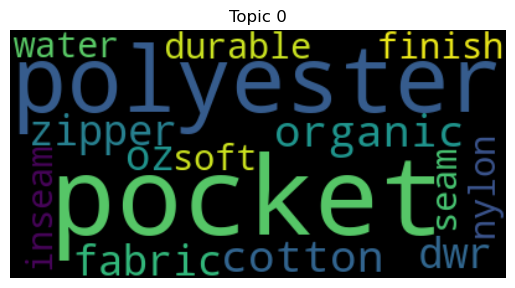

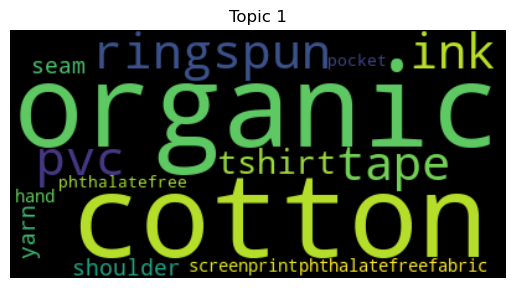

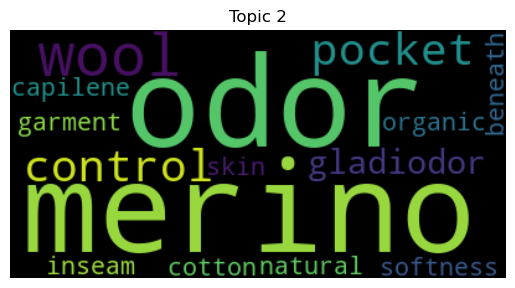

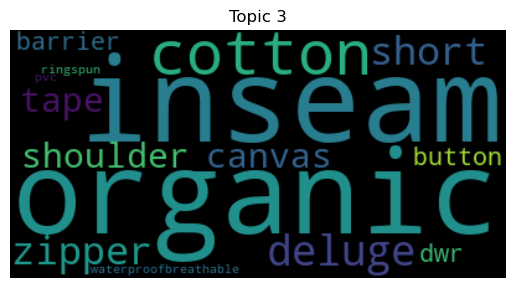

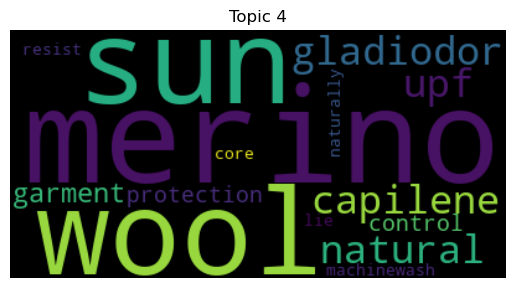

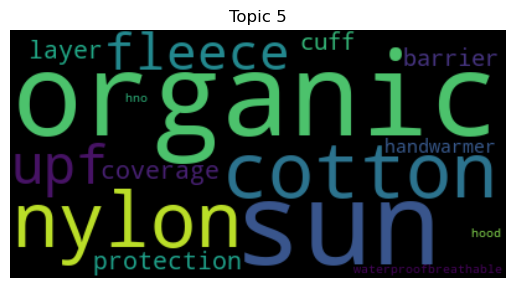

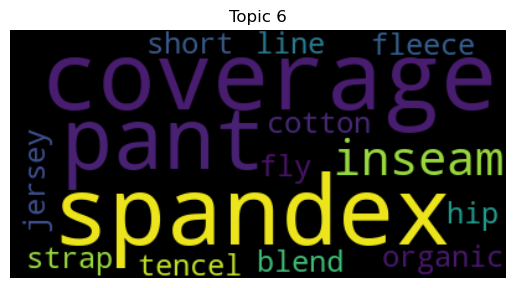

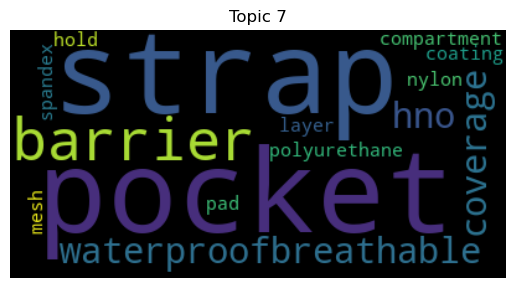

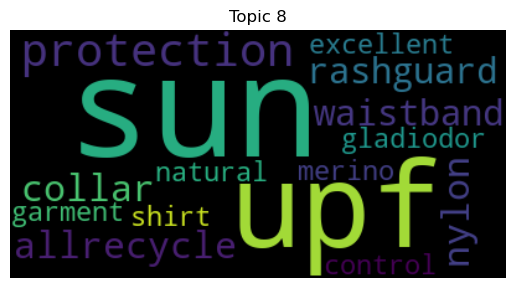

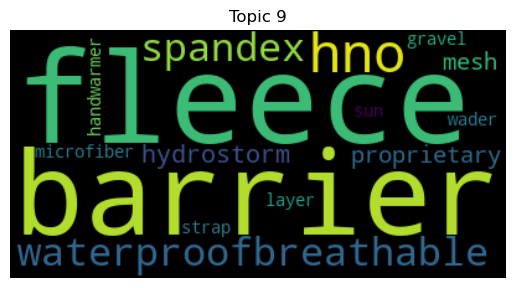

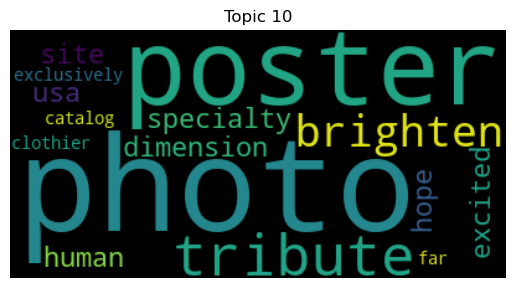

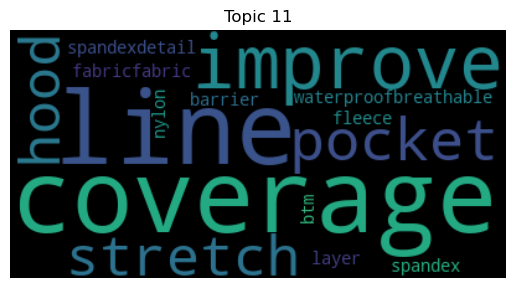

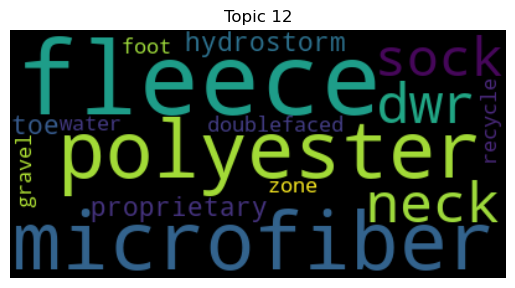

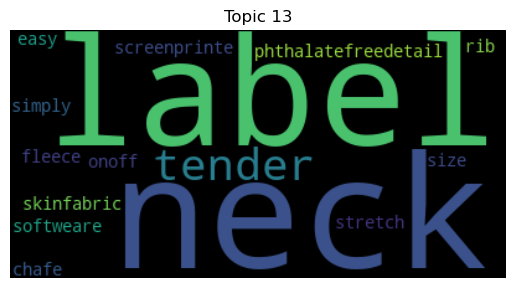

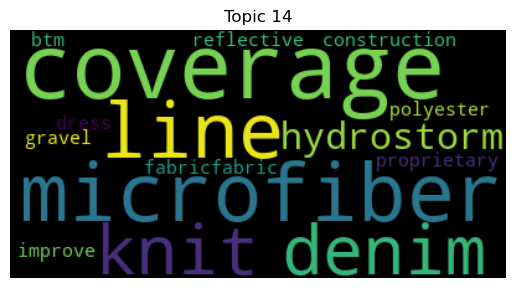

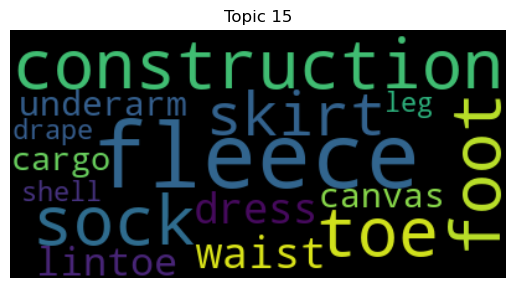

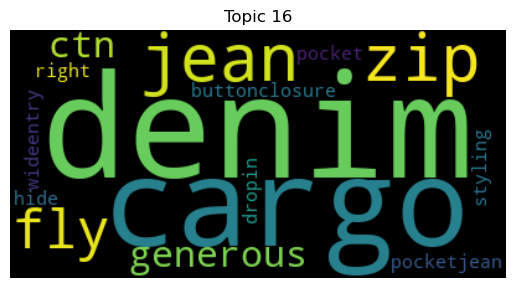

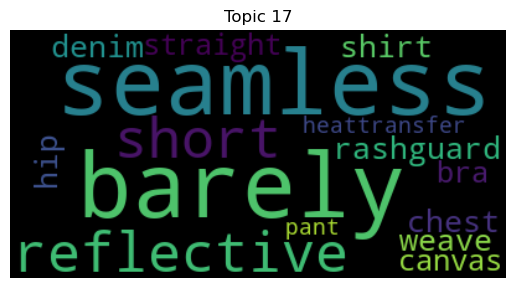

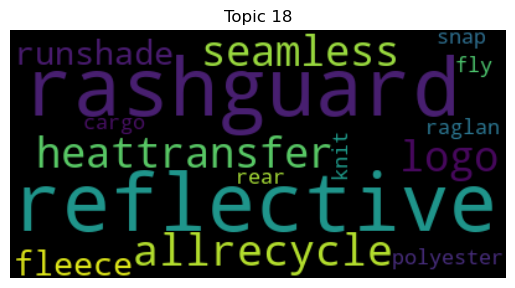

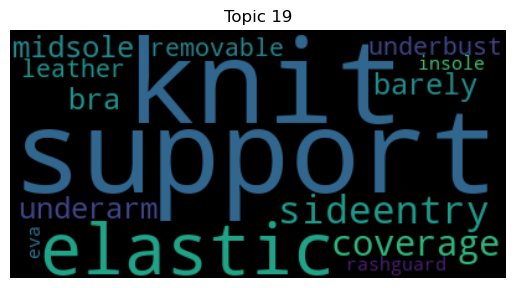

In [58]:
wd = wordcloud.WordCloud()
for topic_num in range(20):
    mots_du_topic = mots_topics[topic_num]
    # Joindre les mots en une seule string
    texte = ' '.join(mots_du_topic)
    cloud = wd.generate(texte)
    plt.imshow(cloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Topic {topic_num}')
    plt.show()

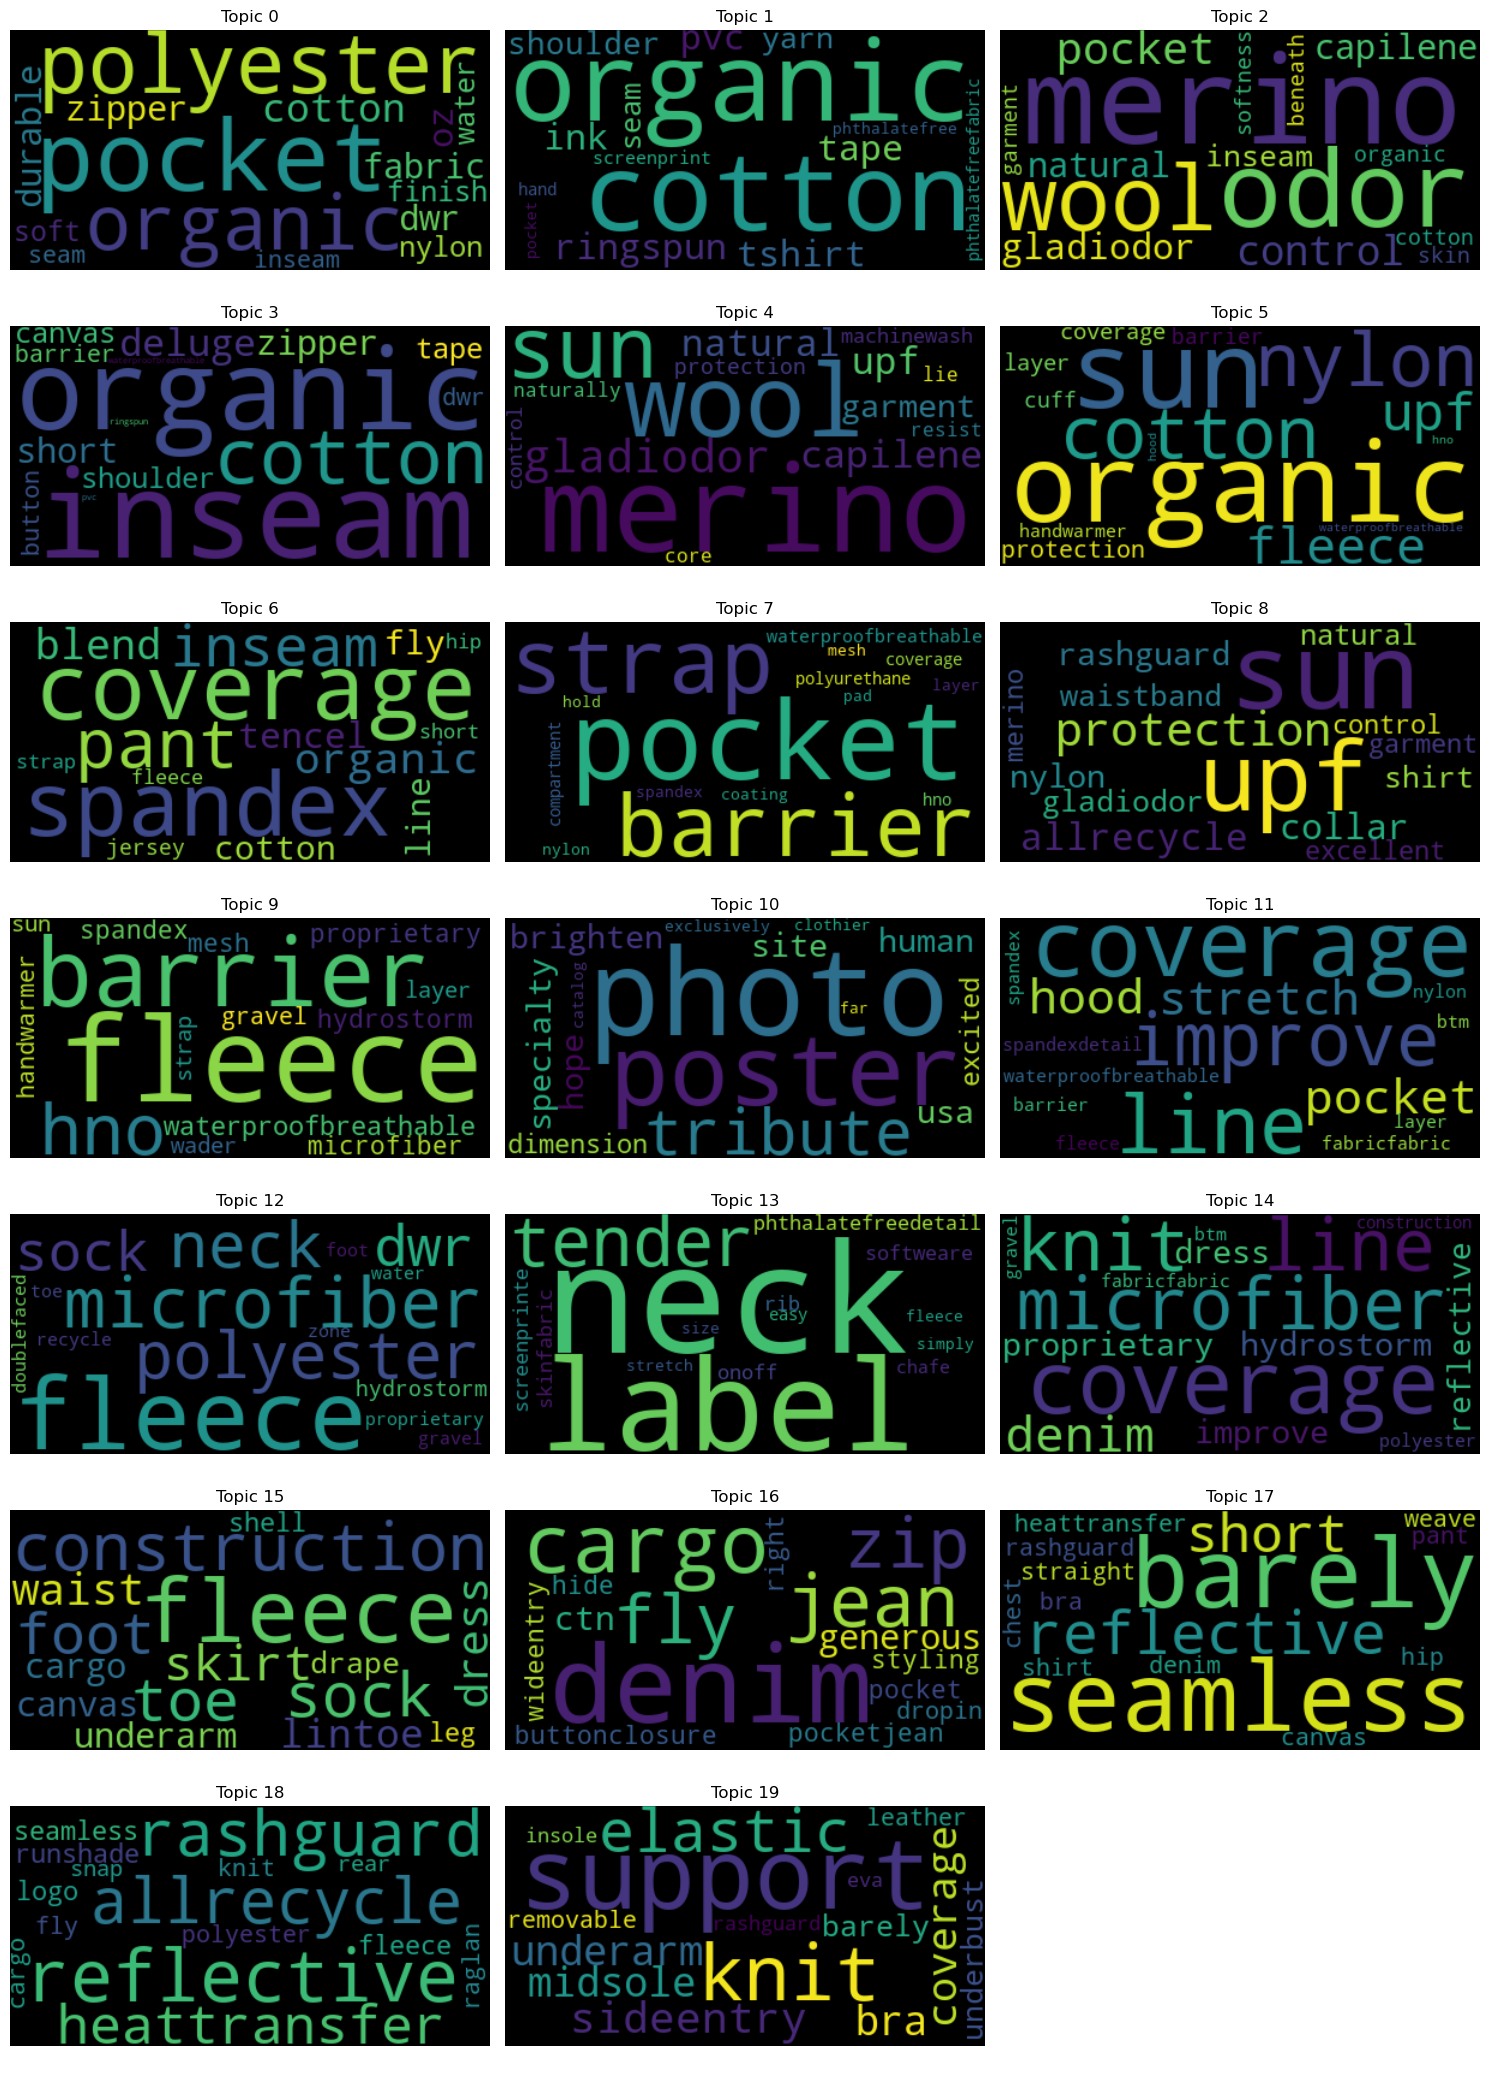

In [62]:

# Calculer le nombre de lignes nécessaires
n_topics = 20
n_cols = 3
n_rows = (n_topics + n_cols - 1) // n_cols  # Arrondi vers le haut

# Créer la figure avec subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3*n_rows))
axes = axes.flatten()  # Pour faciliter l'indexation


for topic_num in range(n_topics):
    indices_du_topic = indices_top15[topic_num]
    mots_du_topic = mots_topics[topic_num]
    poids_du_topic = val_abs_svd_model[topic_num][indices_du_topic]
    
    # Créer le dictionnaire pour ce topic
    freq_dict = dict(zip(mots_du_topic, poids_du_topic))
    
    # Générer le wordcloud
    cloud = wd.generate_from_frequencies(freq_dict)
    
    # Afficher dans le subplot correspondant
    axes[topic_num].imshow(cloud, interpolation='bilinear')
    axes[topic_num].axis('off')
    axes[topic_num].set_title(f'Topic {topic_num}', fontsize=12)

# Masquer les subplots vides s'il y en a
for i in range(n_topics, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()